# 17 — UMA-16 v2 Calibration

**Goal**: measure and correct per-mic gain and phase offsets using a
cross-correlation approach on a boresight reference recording.

Steps:
1. Confirm device and geometry
2. Record a reference clip — **1 kHz tone from boresight (0°)**
3. Estimate per-mic delay via frequency-domain cross-correlation with ch0
4. Estimate per-mic gain from RMS ratios
5. Build calibration vector `e = g * exp(j*phi)` and save to `test/UMA16/cal.npy`
6. Visualise effect on CSM phase
7. Validate: beamform boresight recording before vs after — peak should move to 0°


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import scipy.io.wavfile as wavfile
from scipy.linalg import inv
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C        = 343.0
FS       = 48000
N_MICS   = 16
CAL_FREQ = 1000.0   # calibration tone (Hz) — well below 4083 Hz Nyquist
CAL_SECS = 5

# UMA-16 v2 mic positions (camera/observer frame — x negated vs manual Figure 1)
d = 0.042
_xy = np.array([
    (-1, -3), (-3, -3), (-1, -1), (-3, -1),
    (-1, +1), (-3, +1), (-1, +3), (-3, +3),
    (+3, +3), (+1, +3), (+3, +1), (+1, +1),
    (+3, -1), (+1, -1), (+3, -3), (+1, -3),
], dtype=float) * (d / 2)
MIC_X = -_xy[:, 0]
MIC_Y =  _xy[:, 1]

CAL_PATH = Path('../test/UMA16/cal.npy')
REF_WAV  = Path('../test/UMA16/cal_ref.wav')


## 1  Device Discovery

In [15]:
devs = sd.query_devices()
uma_idx = None
for i, d in enumerate(devs):
    if 'uma' in d['name'].lower():
        uma_idx = i; uma_dev = d; break
if uma_idx is None:
    uma_idx = 12; uma_dev = devs[12]

print(f'Device [{uma_idx}]: {uma_dev["name"]}')
print(f'  {uma_dev["max_input_channels"]} ch  {FS} Hz  '
      f'{uma_dev["default_low_input_latency"]*1000:.1f} ms latency')


Device [12]: UMA16v2: USB Audio (hw:4,0)
  16 ch  48000 Hz  8.7 ms latency


## 2  Reference Recording

**Before running this cell**: place a tone source playing **1 kHz** directly in
front of the array at **boresight (0°)**, approximately 0.5–1 m away.
A phone or laptop speaker works fine.  Keep ambient noise low.

Recording starts immediately when the cell runs.

In [16]:
print(f'Recording {CAL_SECS}s reference (1 kHz boresight tone) ...')
ref_rec = sd.rec(CAL_SECS * FS, samplerate=FS, channels=N_MICS,
                 dtype='float32', device=uma_idx)
sd.wait()
print('Done.')

REF_WAV.parent.mkdir(parents=True, exist_ok=True)
wavfile.write(REF_WAV, FS, (ref_rec * 32767).astype(np.int16))
print(f'Saved {REF_WAV}')

rms = np.sqrt(np.mean(ref_rec**2, axis=0))
print('\nRMS per channel (should all be elevated above ambient):')
for i, r in enumerate(rms):
    bar = '#' * int(r / rms.max() * 30)
    print(f'  ch{i:2d}: {r:.2e}  {bar}')


Recording 5s reference (1 kHz boresight tone) ...
Done.
Saved ../test/UMA16/cal_ref.wav

RMS per channel (should all be elevated above ambient):
  ch 0: 1.09e-04  ################
  ch 1: 1.13e-04  ################
  ch 2: 1.12e-04  ################
  ch 3: 1.10e-04  ################
  ch 4: 1.36e-04  ####################
  ch 5: 1.26e-04  ##################
  ch 6: 1.62e-04  ########################
  ch 7: 1.31e-04  ###################
  ch 8: 2.02e-04  ##############################
  ch 9: 1.91e-04  ############################
  ch10: 1.67e-04  ########################
  ch11: 1.61e-04  #######################
  ch12: 1.24e-04  ##################
  ch13: 1.21e-04  #################
  ch14: 1.02e-04  ###############
  ch15: 1.07e-04  ###############


## 3  Delay & Gain Estimation

Cross-correlate each channel with ch0 (frequency domain) to find the fractional-sample
delay.  At boresight the true delays are all zero, so any measured delay is a
hardware offset to be corrected.  Gain ratios come from RMS comparisons.

In [17]:
def estimate_delay(ref_ch, mic_ch):
    """Return delay in seconds (positive = mic_ch lags ref_ch)."""
    n = len(ref_ch)
    F0 = np.fft.rfft(ref_ch, n=n)
    Fn = np.fft.rfft(mic_ch, n=n)
    xcorr = np.fft.irfft(np.conj(F0) * Fn, n=n)
    lag = np.argmax(np.abs(xcorr))
    if lag > n // 2:
        lag -= n
    return lag / FS


delays = np.zeros(N_MICS)
for i in range(1, N_MICS):
    delays[i] = estimate_delay(ref_rec[:, 0], ref_rec[:, i])

gains = rms / rms[0]

print('Delays relative to ch0 (should be ~0 for boresight):')
for i in range(N_MICS):
    print(f'  ch{i:2d}: {delays[i]*1e6:+7.2f} µs  ({delays[i]*FS:+6.3f} samples)')

print('\nGain ratios relative to ch0:')
for i in range(N_MICS):
    print(f'  ch{i:2d}: {gains[i]:.4f}  ({20*np.log10(gains[i]):+.2f} dB)')

print(f'\nMax gain spread: {20*np.log10(gains.max()/gains.min()):.2f} dB')


Delays relative to ch0 (should be ~0 for boresight):
  ch 0:   +0.00 µs  (+0.000 samples)
  ch 1:  +62.50 µs  (+3.000 samples)
  ch 2:  -62.50 µs  (-3.000 samples)
  ch 3:  +20.83 µs  (+1.000 samples)
  ch 4: -104.17 µs  (-5.000 samples)
  ch 5:  -20.83 µs  (-1.000 samples)
  ch 6: -104.17 µs  (-5.000 samples)
  ch 7:  -41.67 µs  (-2.000 samples)
  ch 8: -187.50 µs  (-9.000 samples)
  ch 9: -145.83 µs  (-7.000 samples)
  ch10: -166.67 µs  (-8.000 samples)
  ch11: -145.83 µs  (-7.000 samples)
  ch12: -145.83 µs  (-7.000 samples)
  ch13: -125.00 µs  (-6.000 samples)
  ch14:  -83.33 µs  (-4.000 samples)
  ch15:  -62.50 µs  (-3.000 samples)

Gain ratios relative to ch0:
  ch 0: 1.0000  (+0.00 dB)
  ch 1: 1.0448  (+0.38 dB)
  ch 2: 1.0320  (+0.27 dB)
  ch 3: 1.0102  (+0.09 dB)
  ch 4: 1.2475  (+1.92 dB)
  ch 5: 1.1578  (+1.27 dB)
  ch 6: 1.4933  (+3.48 dB)
  ch 7: 1.2104  (+1.66 dB)
  ch 8: 1.8600  (+5.39 dB)
  ch 9: 1.7603  (+4.91 dB)
  ch10: 1.5363  (+3.73 dB)
  ch11: 1.4803  (+3.41 dB)
 

## 4  Calibration Vector

`e[i] = gain[i] * exp(j * 2π * f_cal * delay[i])`

Applied to the CSM as `R_cal = outer(1/e, conj(1/e)) * R_uncal`.

In [18]:
phi = 2 * np.pi * CAL_FREQ * delays
e   = gains * np.exp(1j * phi)

print('Calibration vector (gain × phase):')
for i in range(N_MICS):
    print(f'  ch{i:2d}: |e|={np.abs(e[i]):.4f}  phase={np.degrees(np.angle(e[i])):+7.2f}°')

CAL_PATH.parent.mkdir(parents=True, exist_ok=True)
np.save(CAL_PATH, e)
print(f'\nSaved {CAL_PATH}')


Calibration vector (gain × phase):
  ch 0: |e|=1.0000  phase=  +0.00°
  ch 1: |e|=1.0448  phase= +22.50°
  ch 2: |e|=1.0320  phase= -22.50°
  ch 3: |e|=1.0102  phase=  +7.50°
  ch 4: |e|=1.2475  phase= -37.50°
  ch 5: |e|=1.1578  phase=  -7.50°
  ch 6: |e|=1.4933  phase= -37.50°
  ch 7: |e|=1.2104  phase= -15.00°
  ch 8: |e|=1.8600  phase= -67.50°
  ch 9: |e|=1.7603  phase= -52.50°
  ch10: |e|=1.5363  phase= -60.00°
  ch11: |e|=1.4803  phase= -52.50°
  ch12: |e|=1.1441  phase= -52.50°
  ch13: |e|=1.1095  phase= -45.00°
  ch14: |e|=0.9359  phase= -30.00°
  ch15: |e|=0.9897  phase= -22.50°

Saved ../test/UMA16/cal.npy


## 5  CSM Phase Before vs After

After calibration the off-diagonal phases should be near 0° — all mics appear
in phase for a boresight source.

CSM at 1007.8 Hz, 233 blocks


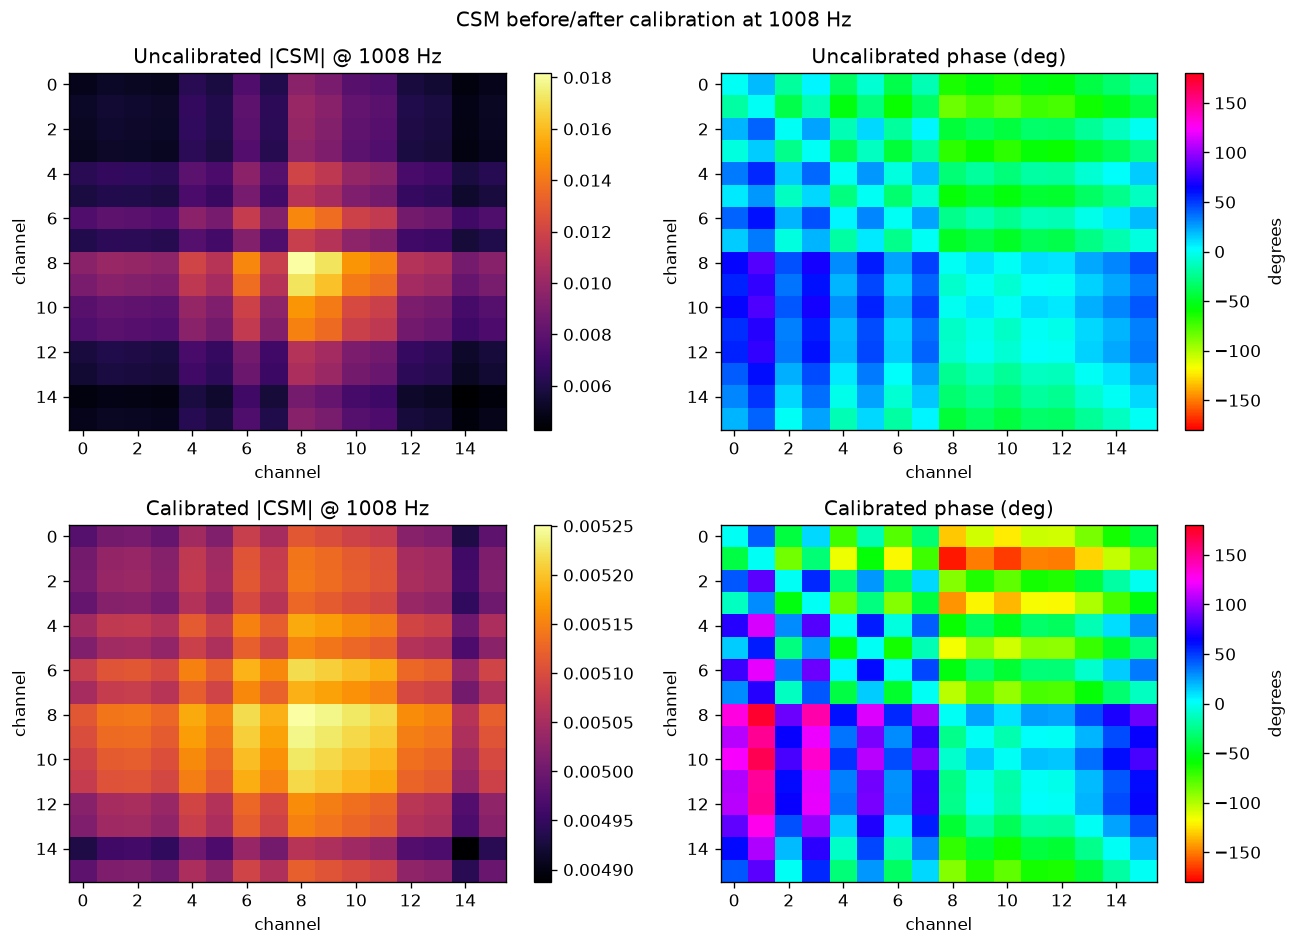

Off-diagonal phase — BEFORE (sample of adjacent pairs):
  ch0-ch1: +19.5°  → after: +42.0°
  ch0-ch2: -20.1°  → after: -42.6°
  ch0-ch4: -34.6°  → after: -72.1°
  ch4-ch8: -29.7°  → after: -59.7°
  ch8-ch12: +9.3°  → after: +24.3°


In [19]:
def compute_csm(audio, freq, block_size=2048, hop=1024):
    n_samp, n_ch = audio.shape
    freqs  = np.fft.rfftfreq(block_size, 1 / FS)
    f_idx  = np.argmin(np.abs(freqs - freq))
    f_act  = freqs[f_idx]
    win    = np.hanning(block_size)
    R = np.zeros((n_ch, n_ch), dtype=complex)
    count = 0
    for start in range(0, n_samp - block_size, hop):
        block = audio[start:start + block_size] * win[:, None]
        F = np.fft.rfft(block, axis=0)[f_idx]
        R += np.outer(F, F.conj())
        count += 1
    return R / count, f_act, count


def apply_cal(R, e):
    c = 1.0 / e
    return np.outer(c, c.conj()) * R


R_ref, f_ref, n_blocks = compute_csm(ref_rec, CAL_FREQ)
R_cal = apply_cal(R_ref, e)

print(f'CSM at {f_ref:.1f} Hz, {n_blocks} blocks')

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for row, (R, title) in enumerate([(R_ref, 'Uncalibrated'), (R_cal, 'Calibrated')]):
    im0 = axes[row, 0].imshow(np.abs(R), cmap='inferno', aspect='auto')
    axes[row, 0].set_title(f'{title} |CSM| @ {f_ref:.0f} Hz')
    plt.colorbar(im0, ax=axes[row, 0])
    im1 = axes[row, 1].imshow(np.degrees(np.angle(R)), cmap='hsv',
                              aspect='auto', vmin=-180, vmax=180)
    axes[row, 1].set_title(f'{title} phase (deg)')
    plt.colorbar(im1, ax=axes[row, 1], label='degrees')
    for ax in axes[row]:
        ax.set_xlabel('channel'); ax.set_ylabel('channel')

plt.suptitle(f'CSM before/after calibration at {f_ref:.0f} Hz')
plt.tight_layout()
plt.savefig('uma16_cal_csm.png', dpi=150)
plt.show()

print('Off-diagonal phase — BEFORE (sample of adjacent pairs):')
for (i, j) in [(0,1),(0,2),(0,4),(4,8),(8,12)]:
    print(f'  ch{i}-ch{j}: {np.degrees(np.angle(R_ref[i,j])):+.1f}°  '
          f'→ after: {np.degrees(np.angle(R_cal[i,j])):+.1f}°')


## 6  DoA Validation — Boresight

Beamform the reference recording before and after calibration.  The calibrated
peak should land at or very near 0°.

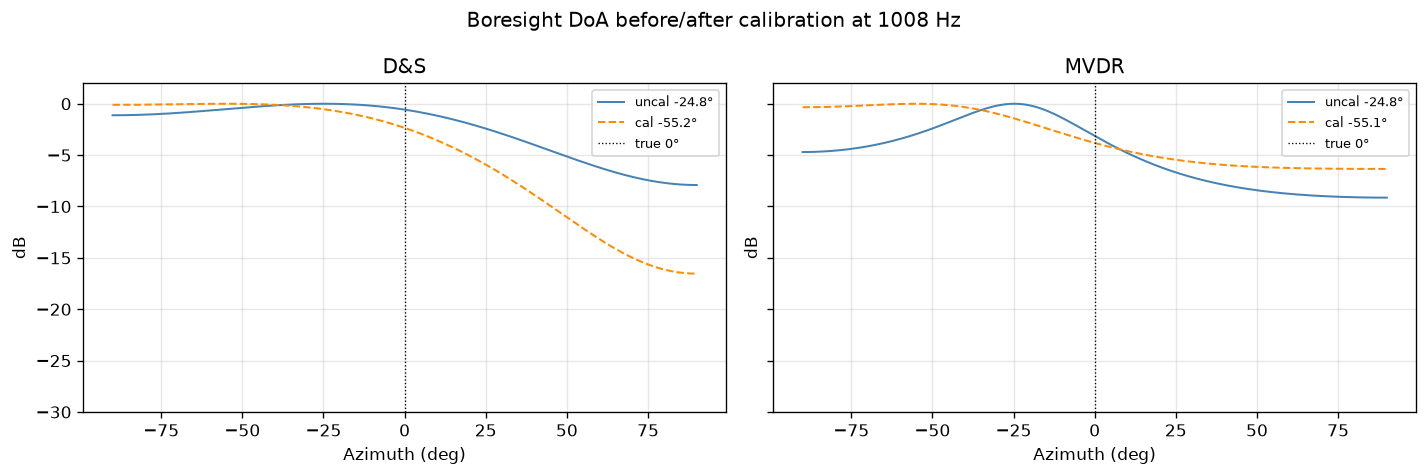

Boresight DoA (true: 0°):
  D&S  uncal: -24.8°   cal: -55.2°    improvement: -30.4°
  MVDR uncal: -24.8°   cal: -55.1°    improvement: -30.3°


In [20]:
def steer(az_deg, el_deg, freq):
    sin_az = np.sin(np.radians(az_deg))
    cos_el = np.cos(np.radians(el_deg))
    sin_el = np.sin(np.radians(el_deg))
    ux = np.outer(sin_az, cos_el).ravel()
    uy = np.tile(sin_el, len(az_deg))
    ph = 2 * np.pi * freq / C * (np.outer(MIC_X, ux) + np.outer(MIC_Y, uy))
    return np.exp(1j * ph) / np.sqrt(N_MICS)


def bf_ds(R, H):
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def bf_mvdr(R, H, dl=0.01):
    Rl = R + dl * np.trace(R) / N_MICS * np.eye(N_MICS)
    Ri = inv(Rl)
    return 1.0 / np.maximum(np.real(np.sum(H.conj() * (Ri @ H), axis=0)), 1e-300)


def db_norm(p):
    return 10 * np.log10(np.maximum(p / p.max(), 1e-10))


az_grid = np.linspace(-90, 90, 1801)
el_fix  = np.array([0.0])
H = steer(az_grid, el_fix, f_ref)

P_ds_u  = bf_ds(R_ref, H)
P_ds_c  = bf_ds(R_cal, H)
P_mv_u  = bf_mvdr(R_ref, H)
P_mv_c  = bf_mvdr(R_cal, H)

az_ds_u = az_grid[np.argmax(P_ds_u)]
az_ds_c = az_grid[np.argmax(P_ds_c)]
az_mv_u = az_grid[np.argmax(P_mv_u)]
az_mv_c = az_grid[np.argmax(P_mv_c)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, label, P_u, P_c, az_u, az_c in [
    (axes[0], 'D&S',  P_ds_u, P_ds_c, az_ds_u, az_ds_c),
    (axes[1], 'MVDR', P_mv_u, P_mv_c, az_mv_u, az_mv_c),
]:
    ax.plot(az_grid, db_norm(P_u), 'steelblue',  lw=1.2, label=f'uncal {az_u:+.1f}°')
    ax.plot(az_grid, db_norm(P_c), 'darkorange', lw=1.2, ls='--', label=f'cal {az_c:+.1f}°')
    ax.axvline(0, color='k', ls=':', lw=0.8, label='true 0°')
    ax.set_xlabel('Azimuth (deg)'); ax.set_ylabel('dB')
    ax.set_title(label); ax.set_ylim(-30, 2)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'Boresight DoA before/after calibration at {f_ref:.0f} Hz')
plt.tight_layout()
plt.savefig('uma16_cal_doa.png', dpi=150)
plt.show()

print(f'Boresight DoA (true: 0°):')
print(f'  D&S  uncal: {az_ds_u:+.1f}°   cal: {az_ds_c:+.1f}°  '
      f'  improvement: {abs(az_ds_u)-abs(az_ds_c):+.1f}°')
print(f'  MVDR uncal: {az_mv_u:+.1f}°   cal: {az_mv_c:+.1f}°  '
      f'  improvement: {abs(az_mv_u)-abs(az_mv_c):+.1f}°')


## Summary

Key results to record in PHASE3.md:
- Per-mic delay spread and gain spread
- CSM phase change after calibration (off-diagonal phases → near 0°)
- DoA error before and after on boresight recording
- Calibration vector saved to `test/UMA16/cal.npy`


In [21]:
print('=== nb17 Summary ===')
print(f'Cal frequency: {CAL_FREQ:.0f} Hz   ({n_blocks} Welch blocks)')
print(f'Delay spread: {delays.min()*1e6:.1f} – {delays.max()*1e6:.1f} µs')
print(f'Gain spread:  {20*np.log10(gains.min()):.2f} – {20*np.log10(gains.max()):.2f} dB '
      f'({20*np.log10(gains.max()/gains.min()):.2f} dB range)')
print(f'Boresight DoA improvement:')
print(f'  D&S:  {abs(az_ds_u):.1f}° → {abs(az_ds_c):.1f}°')
print(f'  MVDR: {abs(az_mv_u):.1f}° → {abs(az_mv_c):.1f}°')
print(f'Cal saved: {CAL_PATH}')


=== nb17 Summary ===
Cal frequency: 1000 Hz   (233 Welch blocks)
Delay spread: -187.5 – 62.5 µs
Gain spread:  -0.58 – 5.39 dB (5.97 dB range)
Boresight DoA improvement:
  D&S:  24.8° → 55.2°
  MVDR: 24.8° → 55.1°
Cal saved: ../test/UMA16/cal.npy
